# 01 - Exploratory Data Analysis

Stage 1 checks the historical international results data and the World Cup 2026 fixture files before any modeling work begins. The emphasis is on data coverage, exact team-name consistency, competition labels, and basic scoring environment summaries.

## Setup

The notebook imports only the Stage 1 loader helpers plus pandas, matplotlib, and seaborn. It expects `data/raw/group_fixtures.csv` and `data/raw/knockout_slots.csv` to exist.

In [3]:
from pathlib import Path
print(Path.cwd())

d:\datacamp competetion\wc2026-forecasting\notebooks


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from config import DATA_RAW
from src.data_loader import clean_results, fetch_international_results, load_fixtures, resolve_team

sns.set_theme(style="whitegrid")

## Load Results And Fixtures

The historical results are cleaned by parsing dates, dropping unplayed rows, keeping matches from the configured Elo start year onward, and preserving the `neutral` flag. Fixtures are loaded separately because group fixtures contain concrete teams while knockout fixtures contain bracket slots.

In [2]:
raw_results = fetch_international_results(force_refresh=False)
results = clean_results(raw_results)

group_path = DATA_RAW / "group_fixtures.csv"
knockout_path = DATA_RAW / "knockout_slots.csv"

group_fixtures, knockout_slots = load_fixtures(group_path, knockout_path)

print(f"Raw results shape: {raw_results.shape}")
print(f"Clean results shape: {results.shape}")
print(f"Date range: {results['date'].min().date()} to {results['date'].max().date()}")
print(f"Unique teams in results: {len(set(results['home_team']) | set(results['away_team']))}")
print(f"Group fixtures shape: {group_fixtures.shape}")
print(f"Knockout slots shape: {knockout_slots.shape}")
print(f"Group fixture date range: {group_fixtures['date_utc'].min()} to {group_fixtures['date_utc'].max()}")
print(f"Knockout slot date range: {knockout_slots['date_utc'].min()} to {knockout_slots['date_utc'].max()}")

Raw results shape: (49390, 9)
Clean results shape: (25256, 9)
Date range: 2000-01-04 to 2026-06-04
Unique teams in results: 321
Group fixtures shape: (72, 6)
Knockout slots shape: (32, 7)
Group fixture date range: 2026-06-11 19:00:00+00:00 to 2026-06-28 02:00:00+00:00
Knockout slot date range: 2026-06-28 19:00:00+00:00 to 2026-07-19 19:00:00+00:00


## Team-Name Consistency Check

This is the most important Stage 1 check. The competition team names must match the historical results exactly, otherwise ratings will not attach to fixture teams. Playoff placeholders are resolved before the check.

In [3]:
teams = sorted(results['home_team'].unique()) + sorted(results['away_team'].unique())
teams = sorted(set(teams))
for t in teams:
    if 'voire' in t.lower() or 'ivor' in t.lower() or 'cote' in t.lower():
        print('Ivory:', t)
    if 'united states' in t.lower() or t == 'USA' or 'america' in t.lower():
        print('USA:', t)
    if 'verde' in t.lower() or 'cape' in t.lower():
        print('Cape:', t)

USA: American Samoa
Cape: Cape Verde
Ivory: Ivory Coast
USA: United States
USA: United States Virgin Islands


In [4]:
from difflib import get_close_matches
from src.data_loader import canonical_team

fixture_teams = pd.concat(
    [group_fixtures["home_team"], group_fixtures["away_team"]],
    ignore_index=True,
).dropna()
wc_teams = sorted({canonical_team(team) for team in fixture_teams})

results_teams = sorted(set(results["home_team"]) | set(results["away_team"]))
results_team_set = set(results_teams)
mismatches = [team for team in wc_teams if team not in results_team_set]

suggested_mapping = {
    team: (get_close_matches(team, results_teams, n=1, cutoff=0.6) or [None])[0]
    for team in mismatches
}

print(f"WC teams found in group fixtures after canonicalization: {len(wc_teams)}")
print(f"Remaining exact spelling mismatches: {len(mismatches)}")
print(mismatches)
print("Suggested mapping dict:")
suggested_mapping

WC teams found in group fixtures after canonicalization: 48
Remaining exact spelling mismatches: 0
[]
Suggested mapping dict:


{}

## Fixture Team Coverage

The table below gives quick historical coverage for each resolved World Cup team. Low counts are not automatically wrong, but they are useful to know before Elo modeling begins.

In [5]:
team_match_counts = (
    pd.concat([results["home_team"], results["away_team"]])
    .value_counts()
    .rename_axis("team")
    .reset_index(name="matches_since_start_year")
)

coverage = pd.DataFrame({"team": wc_teams}).merge(team_match_counts, on="team", how="left")
coverage["matches_since_start_year"] = coverage["matches_since_start_year"].fillna(0).astype(int)
coverage.sort_values("matches_since_start_year").head(20)

,team,matches_since_start_year
11,Curaçao,149
29,New Zealand,176
8,Cape Verde,182
36,Scotland,240
5,Bosnia and Herzegovina,248
7,Canada,255
3,Austria,256
20,Haiti,256
13,DR Congo,265
30,Norway,280


## Competition-Type Audit

No tournament filtering happens in Stage 1. This surface audit lists tournament labels and flags obvious non-senior, non-FIFA, or minor competitions for later Elo downweighting or exclusion decisions.

In [6]:
tournament_counts = results["tournament"].value_counts().rename_axis("tournament").reset_index(name="matches")
tournament_counts

,tournament,matches
0,Friendly,8372
1,FIFA World Cup qualification,5840
2,UEFA Euro qualification,1532
3,African Cup of Nations qualification,1416
4,UEFA Nations League,658
...,...,...
121,South Asian Super Cup,1
122,ConIFA Challenger Cup,1
123,Benedikt Fontana Cup,1
124,Copa Confraternidad,1


In [7]:
flag_terms = [
    "Olympic", "U-", "U23", "U21", "U20", "Youth", "Universiade",
    "Island Games", "CONIFA", "Viva", "Non-FIFA", "AFC Challenge",
    "CFU Caribbean", "Merdeka", "King's Cup", "Nehru", "Lunar New Year",
]
flag_pattern = "|".join(flag_terms)
flagged_tournaments = tournament_counts[
    tournament_counts["tournament"].str.contains(flag_pattern, case=False, na=False)
]
flagged_tournaments

,tournament,matches
12,CFU Caribbean Cup qualification,293
13,Island Games,283
23,CONIFA World Football Cup,101
25,CFU Caribbean Cup,98
28,AFC Challenge Cup qualification,92
29,AFC Challenge Cup,87
31,King's Cup,80
33,Indian Ocean Island Games,68
35,Viva World Cup,60
39,CONIFA European Football Cup,49


## Goal Distribution

This plot checks the empirical total-goals environment that the later Poisson model will need to match.

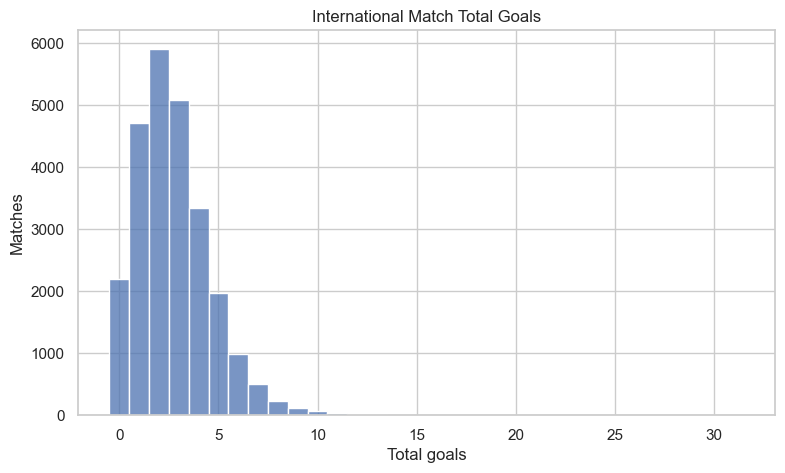

count    25256.000000
mean         2.755702
std          1.981869
min          0.000000
25%          1.000000
50%          2.000000
75%          4.000000
max         31.000000
Name: total_goals, dtype: float64

In [8]:
plot_results = results.assign(total_goals=results["home_score"] + results["away_score"])

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(plot_results["total_goals"], bins=range(0, int(plot_results["total_goals"].max()) + 2), discrete=True, ax=ax)
ax.set_title("International Match Total Goals")
ax.set_xlabel("Total goals")
ax.set_ylabel("Matches")
plt.show()

plot_results["total_goals"].describe()

## Home Vs Neutral Environment

The World Cup mostly uses neutral-site logic, while historical home advantage should only be learned from genuinely non-neutral matches. These summaries compare average goals and home-team win rate by the dataset's `neutral` flag.

In [9]:
home_neutral = plot_results.assign(
    home_win=plot_results["home_score"] > plot_results["away_score"],
    avg_match_goals=plot_results["total_goals"],
)

neutral_summary = (
    home_neutral.groupby("neutral")
    .agg(
        matches=("date", "size"),
        avg_home_goals=("home_score", "mean"),
        avg_away_goals=("away_score", "mean"),
        avg_total_goals=("avg_match_goals", "mean"),
        home_win_rate=("home_win", "mean"),
    )
    .reset_index()
)
neutral_summary

,neutral,matches,avg_home_goals,avg_away_goals,avg_total_goals,home_win_rate
0,False,18070,1.693470,1.020863,2.714333,0.507692
1,True,7186,1.517256,1.342471,2.859727,0.415113


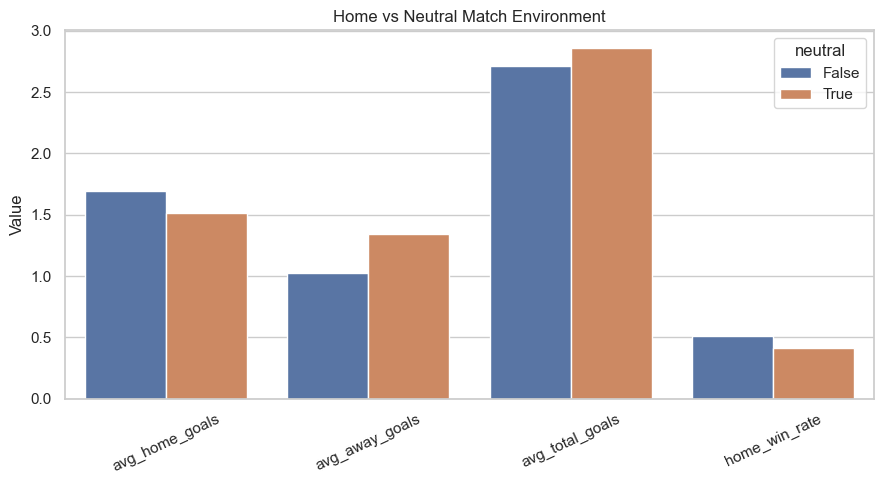

In [10]:
summary_long = neutral_summary.melt(
    id_vars="neutral",
    value_vars=["avg_home_goals", "avg_away_goals", "avg_total_goals", "home_win_rate"],
    var_name="metric",
    value_name="value",
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=summary_long, x="metric", y="value", hue="neutral", ax=ax)
ax.set_title("Home vs Neutral Match Environment")
ax.set_xlabel("")
ax.set_ylabel("Value")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()